# 1 Imports y Setup

In [1]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import cv2
import os

# Configuración de visualización
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

# 2 Descargamos el Dataset

In [2]:
# CELDA 2: Setup del Dataset
"""
⚠️ Primera ejecución: descarga ~750MB (5-10 min)
✅ Siguientes ejecuciones: usa cache (instantáneo)
"""

import kagglehub
from pathlib import Path

# Ruta típica de cache de kagglehub
cache_path = Path.home() / ".cache" / "kagglehub" / "datasets" / "jessicali9530" / "stanford-dogs-dataset"

if cache_path.exists():
    print("✅ Dataset encontrado en cache (sin necesidad de descargar)")
else:
    print("📥 Primera ejecución detectada. Descargando dataset (~750MB, 5-10 min)...")

try:
    path = kagglehub.dataset_download("jessicali9530/stanford-dogs-dataset")
    print(f"✅ Dataset listo en: {path}")
except Exception as e:
    print(f"❌ Error: {e}")
    path = None

✅ Dataset encontrado en cache (sin necesidad de descargar)
✅ Dataset listo en: C:\Users\yeder\.cache\kagglehub\datasets\jessicali9530\stanford-dogs-dataset\versions\2


# 3 Definicion de la clase StanfordDogsEDA

In [3]:
class StanfordDogsEDA:
    def __init__(self, dataset_path):
        self.dataset_path = Path(dataset_path)
        self.images_path = self.dataset_path / "images" / "Images"
        self.annotations_path = self.dataset_path / "annotations" / "Annotation"
        
    def analyze_dataset(self):
        print("🔍 Analizando estructura del dataset...")
        
        # 1. Listar razas y contar imágenes
        breeds = []
        image_counts = []
        
        for breed_dir in self.images_path.iterdir():
            if breed_dir.is_dir():
                breed_name = breed_dir.name.split('-')[-1]
                num_images = len(list(breed_dir.glob("*.jpg")))
                breeds.append(breed_name)
                image_counts.append(num_images)
        
        # 2. Crear DataFrame
        df = pd.DataFrame({'Breed': breeds, 'Image_Count': image_counts})
        df = df.sort_values('Image_Count', ascending=False)
        
        print(f"📊 Total de razas: {len(breeds)}")
        print(f"🖼️ Total de imágenes: {df['Image_Count'].sum()}")
        print(f"📈 Promedio de imágenes por raza: {df['Image_Count'].mean():.1f}")
        
        # 3. Visualizaciones
        self._plot_breed_distribution(df)
        self._analyze_image_sizes()
        self._sample_images_visualization()
        
        return df
    
    def _plot_breed_distribution(self, df):
        plt.figure(figsize=(15, 10))
        
        plt.subplot(2, 2, 1)
        plt.hist(df['Image_Count'], bins=30, alpha=0.7, color='skyblue')
        plt.title('Distribución de Imágenes por Raza')
        plt.xlabel('Número de Imágenes')
        plt.ylabel('Frecuencia')
        
        plt.subplot(2, 2, 2)
        top_20 = df.head(20)
        plt.barh(range(len(top_20)), top_20['Image_Count'])
        plt.yticks(range(len(top_20)), top_20['Breed'])
        plt.title('Top 20 Razas con Más Imágenes')
        plt.xlabel('Número de Imágenes')
        
        plt.subplot(2, 2, 3)
        bottom_20 = df.tail(20)
        plt.barh(range(len(bottom_20)), bottom_20['Image_Count'])
        plt.yticks(range(len(bottom_20)), bottom_20['Breed'])
        plt.title('Top 20 Razas con Menos Imágenes')
        plt.xlabel('Número de Imágenes')
        
        plt.subplot(2, 2, 4)
        plt.boxplot(df['Image_Count'])
        plt.title('Boxplot - Distribución de Imágenes')
        plt.ylabel('Número de Imágenes')
        
        plt.tight_layout()
        plt.show()
    
    def _analyze_image_sizes(self):
        print("📏 Analizando dimensiones de imágenes...")
        
        sample_images = list(self.images_path.rglob("*.jpg"))[:100]
        sizes = []
        
        for img_path in sample_images:
            try:
                img = cv2.imread(str(img_path))
                if img is not None:
                    h, w, c = img.shape
                    sizes.append((w, h))
            except:
                continue
        
        sizes = np.array(sizes)
        print(f"📐 Dimensiones promedio: {sizes.mean(axis=0)}")
        print(f"📐 Dimensión mínima: {sizes.min(axis=0)}")
        print(f"📐 Dimensión máxima: {sizes.max(axis=0)}")
        
        plt.figure(figsize=(10, 5))
        plt.scatter(sizes[:, 0], sizes[:, 1], alpha=0.6)
        plt.xlabel('Ancho (px)')
        plt.ylabel('Alto (px)')
        plt.title('Distribución de Resoluciones de Imágenes')
        plt.show()
    
    def _sample_images_visualization(self):
        print("🖼️ Mostrando muestras de imágenes...")
        
        fig, axes = plt.subplots(3, 5, figsize=(20, 12))
        breeds = [d for d in self.images_path.iterdir() if d.is_dir()]
        selected_breeds = np.random.choice(breeds, 3, replace=False)
        
        for i, breed_dir in enumerate(selected_breeds):
            breed_images = list(breed_dir.glob("*.jpg"))
            sample_images = np.random.choice(breed_images, 5, replace=False)
            
            for j, img_path in enumerate(sample_images):
                img = cv2.imread(str(img_path))
                img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                
                axes[i, j].imshow(img_rgb)
                axes[i, j].set_title(f"{breed_dir.name.split('-')[-1]}\n{img.shape[1]}x{img.shape[0]}", 
                                   fontsize=8)
                axes[i, j].axis('off')
        
        plt.tight_layout()
        plt.show()

# 4 Instanciar y Ejecutar Analisis basico

🔍 Analizando estructura del dataset...
📊 Total de razas: 120
🖼️ Total de imágenes: 20580
📈 Promedio de imágenes por raza: 171.5


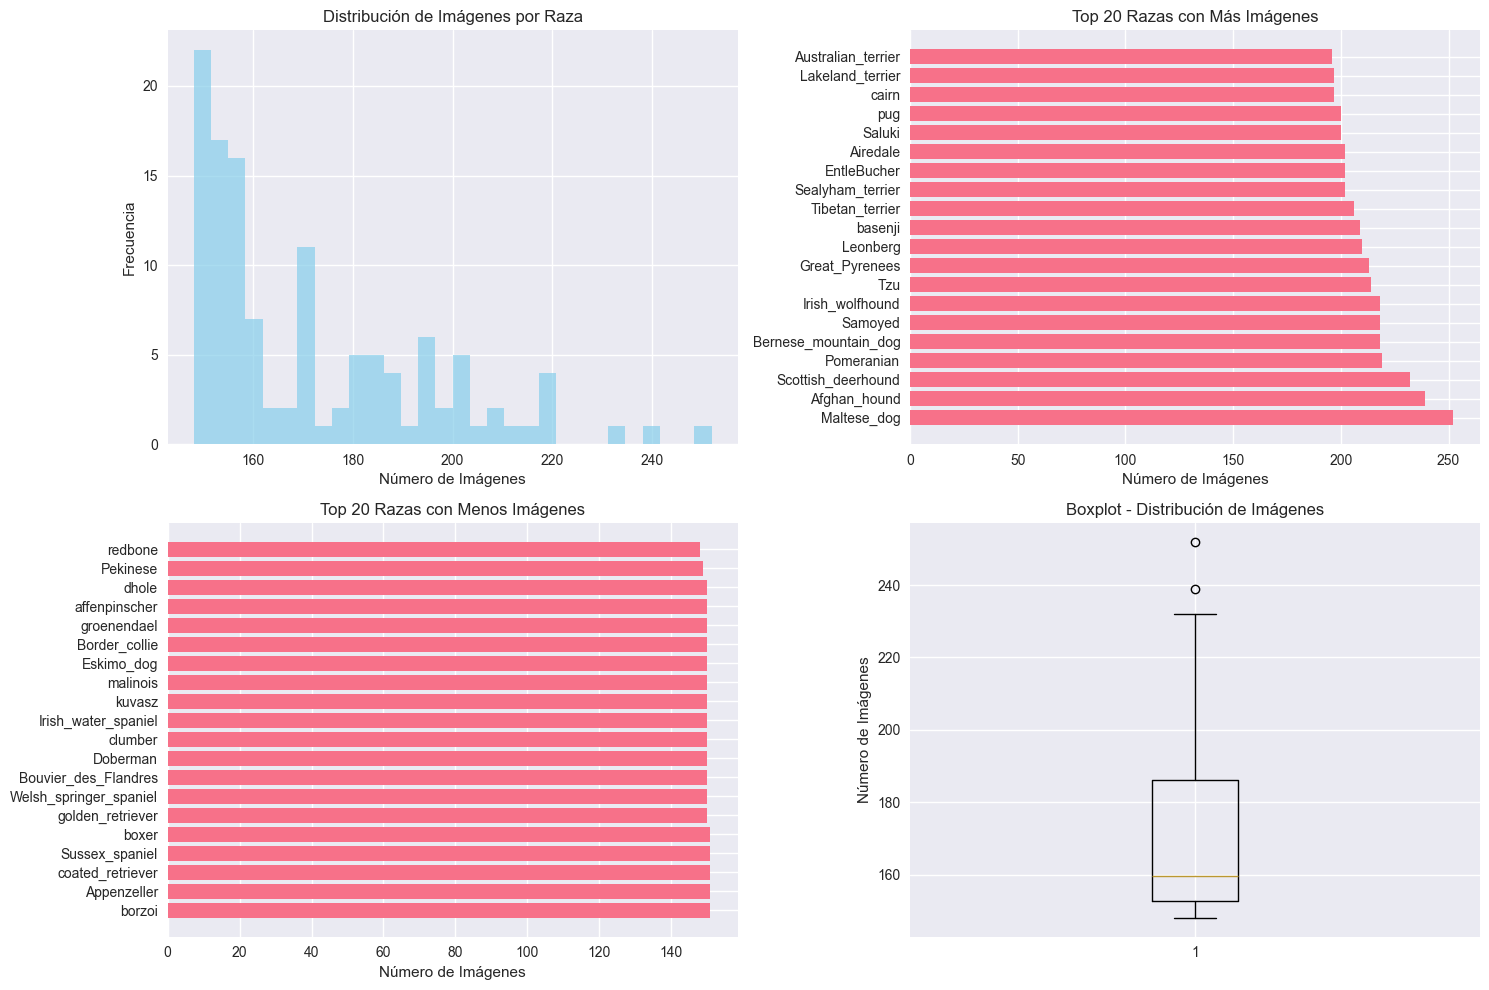

📏 Analizando dimensiones de imágenes...
📐 Dimensiones promedio: [442.55 404.65]
📐 Dimensión mínima: [157 211]
📐 Dimensión máxima: [887 853]


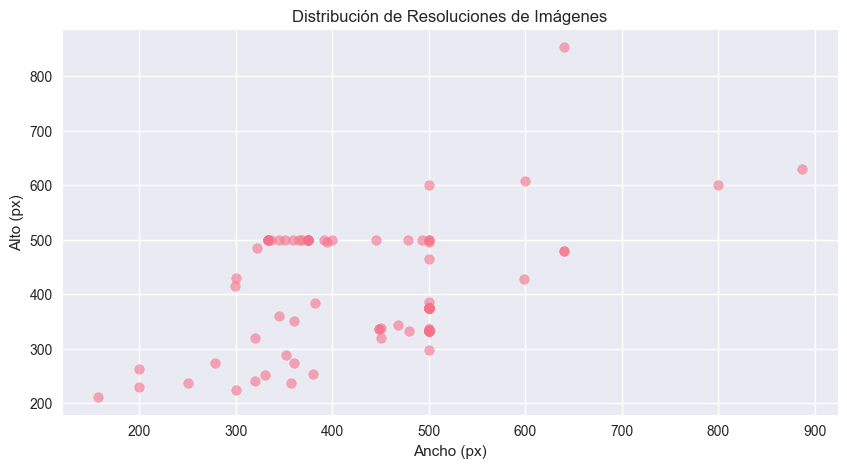

🖼️ Mostrando muestras de imágenes...


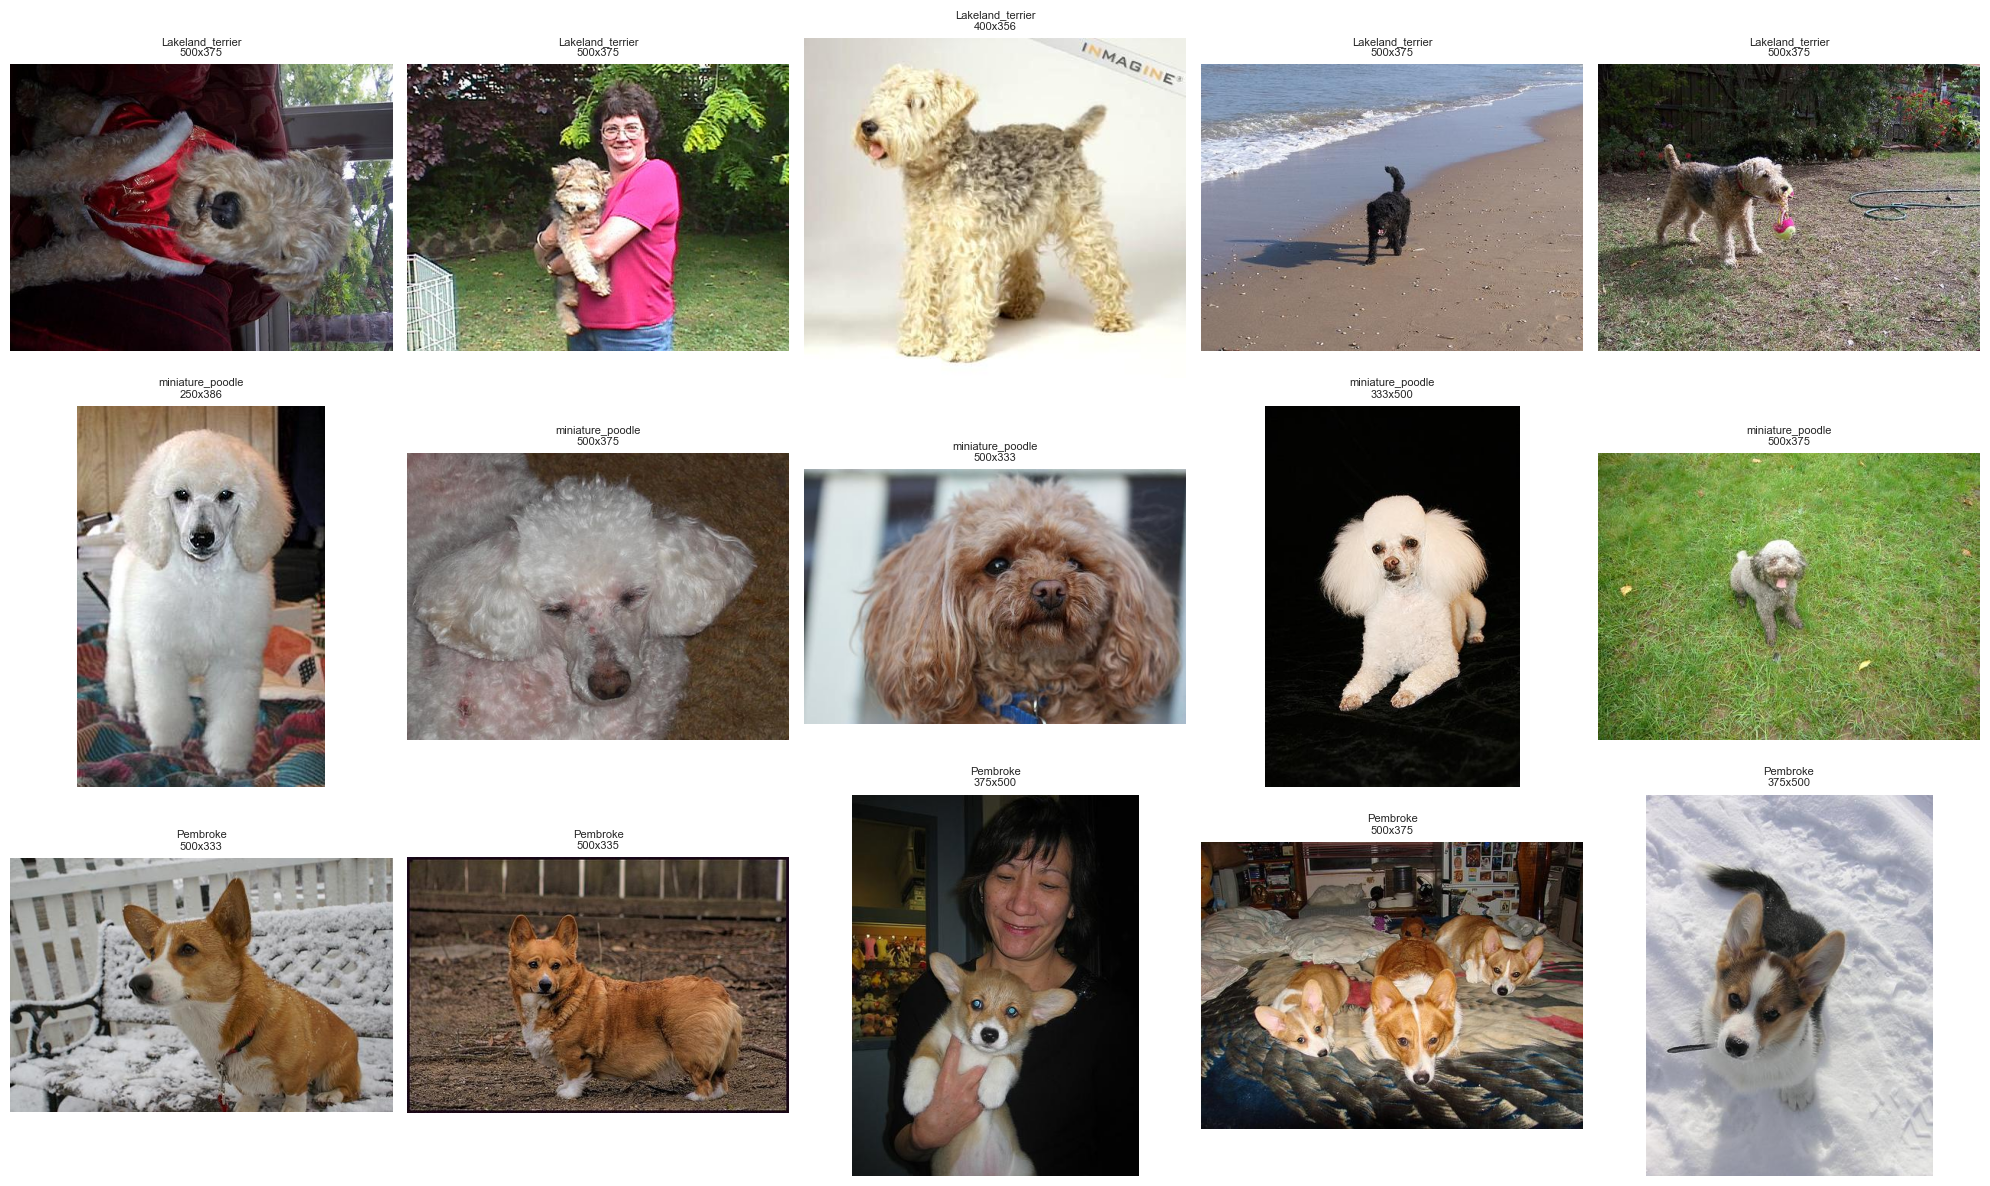

In [4]:
eda = StanfordDogsEDA(path)
df_breeds = eda.analyze_dataset()

# 5 Analisis estadistico detallado

In [5]:
print("📊 ESTADÍSTICAS DESCRIPTIVAS")
print(df_breeds.describe())
print(f"\n🔢 Balance del dataset:")
print(f"Desviación estándar: {df_breeds['Image_Count'].std():.2f}")
print(f"Coeficiente de variación: {(df_breeds['Image_Count'].std() / df_breeds['Image_Count'].mean() * 100):.2f}%")

📊 ESTADÍSTICAS DESCRIPTIVAS
       Image_Count
count   120.000000
mean    171.500000
std      23.220898
min     148.000000
25%     152.750000
50%     159.500000
75%     186.250000
max     252.000000

🔢 Balance del dataset:
Desviación estándar: 23.22
Coeficiente de variación: 13.54%
